# 6. HW_L04_01_Deep_Learning

# 1. Basic Concepts and Tensor Operations

Before implementing deep learning models, it is essential to be familiar with the basic data structures (tensors) and the mathematical operations performed on them.

## Tensor Dimension Management and Reshaping

A large portion of programming errors in deep learning comes from mismatched matrix dimensions.

1. Create a synthetic tensor named `images` with the following dimensions:
   `(Batch_Size=32, Channels=3, Height=64, Width=64)`

   Create it so that it displays a batch of colorful images.

2. Reshape the tensor so that it is ready to be fed into a fully connected layer.
   The output shape should be `(32, 12288)`.

   (Note: `12288 = 64 × 64 × 3`)

3. Change the order of the dimensions for visualization with `Matplotlib`:
   `(Height, Width, Channels)`

   Use it in situations where libraries expect data in PyTorch format:
   `(Channels, Height, Width)`

   To do this, use the `permute()` method first, and make sure the final shape is `(64, 64, 3)`.


In [144]:
import os

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

1. Create a synthetic tensor named `images` with the following dimensions:
   `(Batch_Size=32, Channels=3, Height=64, Width=64)`

In [20]:
torch.manual_seed(42) # Fixed random
images = torch.rand(32, 3, 64, 64)
print(images.shape)

torch.Size([32, 3, 64, 64])


2. Reshape the tensor so that it is ready to be fed into a fully connected layer.
   The output shape should be `(32, 12288)`.

   (Note: `12288 = 64 × 64 × 3`)


In [21]:
flatten_images = torch.flatten(images, start_dim=1)
print(flatten_images.shape)

torch.Size([32, 12288])


In [22]:
images[0]

tensor([[[0.8823, 0.9150, 0.3829,  ..., 0.1587, 0.6542, 0.3278],
         [0.6532, 0.3958, 0.9147,  ..., 0.2083, 0.3289, 0.1054],
         [0.9192, 0.4008, 0.9302,  ..., 0.5535, 0.4117, 0.3510],
         ...,
         [0.1457, 0.1499, 0.3298,  ..., 0.9624, 0.6400, 0.7409],
         [0.1709, 0.5797, 0.6340,  ..., 0.6885, 0.2405, 0.5956],
         [0.9199, 0.1247, 0.3573,  ..., 0.6752, 0.2058, 0.5027]],

        [[0.1458, 0.9024, 0.9217,  ..., 0.1868, 0.6352, 0.8431],
         [0.9549, 0.4435, 0.6924,  ..., 0.1168, 0.7160, 0.5462],
         [0.1616, 0.1054, 0.8614,  ..., 0.4531, 0.4736, 0.9448],
         ...,
         [0.4309, 0.3986, 0.1907,  ..., 0.9444, 0.2848, 0.3776],
         [0.7948, 0.6855, 0.1009,  ..., 0.6147, 0.7747, 0.2323],
         [0.5840, 0.9795, 0.3277,  ..., 0.3549, 0.1263, 0.1280]],

        [[0.5027, 0.4195, 0.8893,  ..., 0.3084, 0.1567, 0.7860],
         [0.7310, 0.9307, 0.2847,  ..., 0.8432, 0.8307, 0.0897],
         [0.7021, 0.5967, 0.7744,  ..., 0.8485, 0.4520, 0.

In [23]:
flatten_images[0]

tensor([0.8823, 0.9150, 0.3829,  ..., 0.5368, 0.2389, 0.2095])

3. Change the order of the dimensions for visualization with `Matplotlib`:
   `(Height, Width, Channels)`

   Use it in situations where libraries expect data in PyTorch format:
   `(Channels, Height, Width)`

   To do this, use the `permute()` method first, and make sure the final shape is `(64, 64, 3)`.


Plot image number of 1 :


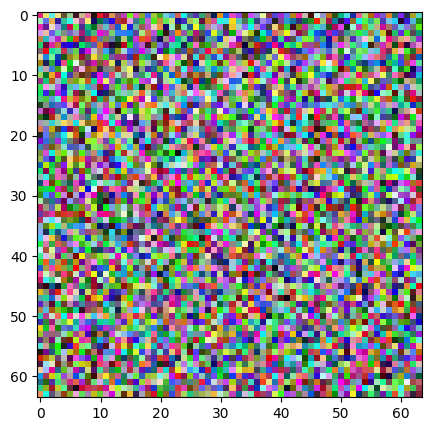

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
number_of_image = 0
print(f"Plot image number of {number_of_image + 1} :")
img = images[number_of_image].permute(1, 2, 0) # C,H,W change to H,W,C
ax.imshow(img);


### All Plot

Create a subplot grid with dimensions $4 \times 8 = 32$:  

`fig, axes = plt.subplots(4, 8, figsize=(16, 8))`

---

The plot index is determined by `i`, obtained via `enumerate`. Since there are 32 images, `i` ranges from 0 to 31.
By using `axes.flat`, we replace two nested loops with a single loop to iterate through the subplot positions.   

---

In the `matplotlib` package, drawing an image requires the order `(Height, Width, Channels)`. However, in the tensor, the order is `(Channels, Height, Width)`. Therefore, we must swap the dimensions using the `permute` command:   

`img = images[i].permute(1, 2, 0)`

---

Each image is then plotted:   

`ax.imshow(img)`

---

Since the axes are not meaningful in this context, they are disabled:   

`ax.axis("off")`

---

Finally, we adjust the layout to be standardized:    

`plt.tight_layout()`


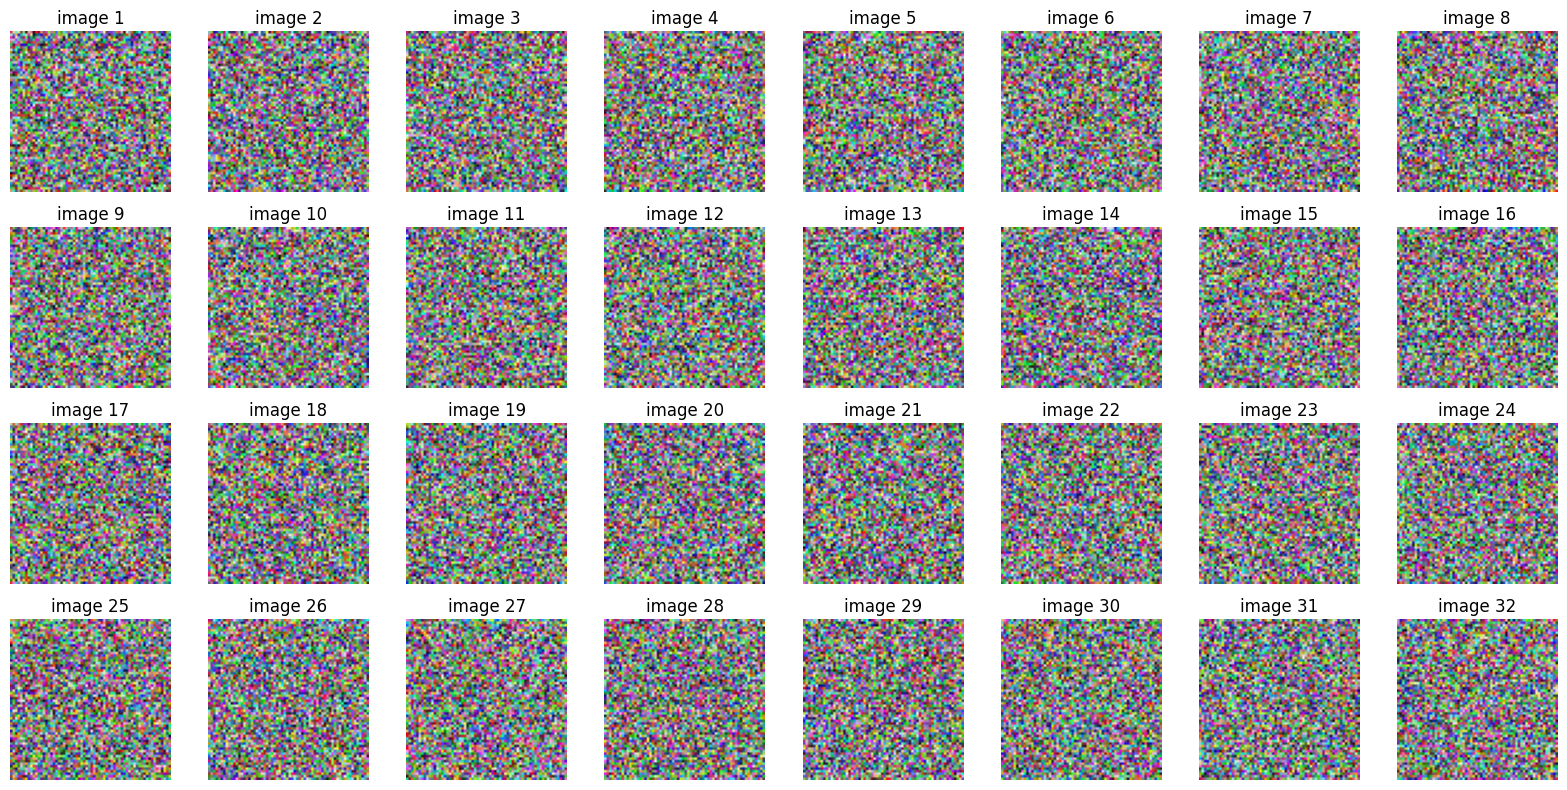

In [25]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat): # axes.flat = row 4 and column 8

    img = images[i].permute(1, 2, 0)  # C,H,W change to H,W,C
    # (3 channel, 64 hight, 64 width) change to (64 hight, 64 width, 33 channel)

    ax.imshow(img)
    ax.set_title(f"image {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Automatic Gradient Computation

1. Define the variable `x` as a tensor with the value `2.0` and enable `requires_grad=True` for it.
2. Implement the function  $y = x^3 + 5x^2 + 2$

3. Manually compute the derivative $\frac{dy}{dx}$ at `x = 2`.
4. Use the `backward()` method on $y$ to compute the gradient, then print the value of `x.grad`. Compare the result with your manual calculation.

With this, we want to compute the gradient.



1. Define the variable `x` as a tensor with the value `2.0` and enable `requires_grad=True` for it.

`requires_grad=True` tells PyTorch:

"Track this tensor for gradient computation."

In other words, if you perform operations on this tensor, PyTorch keeps track of those operations in the computational graph so that you can later compute derivatives using `backward()`.


In [26]:
x = torch.tensor(2.0, requires_grad=True)
print(x)

tensor(2., requires_grad=True)


2. Implement the function  $y = x^3 + 5x^2 + 2$


In [27]:
y = x**3 + 5*(x**2) + 2
print(y)

tensor(30., grad_fn=<AddBackward0>)


3. Manually compute the derivative $\frac{dy}{dx}$ at `x = 2`.

Manual Calculation

First, we differentiate the function

$$
y = x^3 + 5x^2 + 2
$$

with respect to $x$:

$$
\frac{dy}{dx} = 3x^2 + 10x
$$

Now substitute $x = 2$:

$$
\left.\frac{dy}{dx}\right|_{x=2} = 3(2)^2 + 10(2) = 3(4) + 20 = 12 + 20 = 32
$$

In [28]:
y_x = 3*(x**2) + 10*x
print(f"gradiant dy/dx [x=2] = {y_x}")

gradiant dy/dx [x=2] = 32.0


4. Use the `backward()` method on $y$ to compute the gradient, then print the value of `x.grad`. Compare the result with your manual calculation.

In [29]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 5*(x**2) + 2
print(f"x = {x} and y = {y}")
y_x = 3*(x**2) + 10*x
print(f"manual gradiant dy/dx [x=2] = {y_x}")

y.backward()
print(f"by backward dy/dx [x=2] =     {x.grad}")

x = 2.0 and y = 30.0
manual gradiant dy/dx [x=2] = 32.0
by backward dy/dx [x=2] =     32.0


### CPU vs GPU Performance Comparison

1. Check whether **GPU (CUDA)** hardware is available in your runtime environment.
2. Create two large matrices, for example with dimensions `1000 x 1000`, on the CPU and measure the time required for their matrix multiplication.
3. Repeat the same operation after moving the matrices to the GPU, and record the execution time. Report the difference in processing speed.


### GPU off and on

This code run in google colab

1. Check whether **GPU (CUDA)** hardware is available in your runtime environment.

- GPU is off    
- GPU is on

In [1]:
# CPU is on
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())

False
0


In [1]:
# GPU is on
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())

True
1


2. Create two large matrices, for example with dimensions `1000 x 1000`, on the CPU and measure the time required for their matrix multiplication.

In [2]:
# CPU is on
import torch
torch.manual_seed(42)
M1 = torch.randn(1000, 1000, device="cpu") # difalt device is CPU
M2 = torch.randn(1000, 1000, device="cpu") # difalt device is CPU
%timeit torch.matmul(M1, M2)


40.6 ms ± 10.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


3. Repeat the same operation after moving the matrices to the GPU, and record the execution time. Report the difference in processing speed.

In [4]:
# GPU is on
import torch
torch.manual_seed(42)
M1 = torch.randn(1000, 1000, device="cuda") # difalt device is GPU
M2 = torch.randn(1000, 1000, device="cuda") # difalt device is GPU
%timeit torch.matmul(M1, M2)

663 µs ± 1.07 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Time run for CPU is 40.6 ms

Time run for GPU is 663 µs

- `ms` = millisecond = $10^{-3}$ seconds
- `us` = microsecond = $10^{-6}$ seconds



# Part 2

### 2. Regression Problem (Medical Cost Prediction)

**Problem Description:** The objective is to design a model capable of predicting an individual's annual medical expenses based on features such as age, Body Mass Index (BMI), number of children, and smoking status.

**Challenge:** The relationship between the input variables and the final cost is entirely non-linear. Simple linear models are unable to capture the complexity of these relationships.


### 2.1 Implementation Steps:

**1. Data Preprocessing:**
*   Convert categorical variables such as `sex`, `smoker`, and `region` into numerical data using **One-Hot Encoding**.
*   **Standardization:** Normalize continuous variables (`age`, `bmi`). Keeping inputs on the same scale is vital for neural network convergence.
*   Convert the final data into PyTorch tensor format (`FloatTensor`).

**2. Baseline Model:**
*   Train a **Linear Regression** model using the `Scikit-Learn` library.
*   Calculate the **Mean Squared Error (MSE)** on the test data.

**3. Neural Network Model:**
*   Create a fully connected neural network using `nn.Sequential` with the following architecture:
    *   **Input Layer:** Proportionate to the number of features.
    *   **Hidden Layers:** Two layers with 64 neurons each and **ReLU** activation functions.
    *   **Output Layer:** 1 neuron (for predicting the cost amount).
*   Use `MSELoss` as the cost function and the **Adam** optimizer with a learning rate of `0.01`.
*   Train the model with `epochs = 100`.

**4. Results Analysis:**
*   Compare the final neural network error (**Test Loss**) with the Linear Regression model.
*   Explain why using the **ReLU** activation function helps the model better learn non-linear relationships.


In [1]:
import os

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

Read data

In [2]:
data_set = [f for f in os.listdir() if f.endswith(".csv")] # csv file
print(f"name file : {data_set}")
df = pd.read_csv(data_set[0])

# or
# df = pd.read_csv("insurance.csv")

medical_dataset = df.copy() # save main data
medical_dataset.head()

name file : ['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Dataset Description

The dataset contains the following features:

- **age**: Age of the primary beneficiary.
- **sex**: Insurance contractor gender (female, male).
- **bmi**: Body Mass Index, providing an understanding of body weight relative to height ($kg/m^2$).
- **children**: Number of children covered by health insurance / Number of dependents.
- **smoker**: Smoking status (yes, no).
- **region**: The beneficiary's residential area in the US (northeast, southeast, southwest, northwest).
- **charges**: Individual medical costs billed by health insurance (Target Variable).


In [3]:
medical_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Dataset has NOT null-value

In [4]:
medical_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
# types of each columns
pd.DataFrame(medical_dataset.dtypes).reset_index().rename(columns={"index":"Titel", 0:"Type"})

,Titel,Type
0,age,int64
1,sex,str
2,bmi,float64
3,children,int64
4,smoker,str
5,region,str
6,charges,float64


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# 1. X and y
TARGET = "charges"
X = medical_dataset.drop(columns=TARGET)
y = medical_dataset[TARGET]

# 2. type value
type_col = (pd.DataFrame(X.dtypes)
            .reset_index()
            .rename(columns={"index":"Titel", 0:"Type"}))

MASK_CATEGURICAL = type_col["Type"].eq("str")

#col:age and bmi
numerical_col = type_col[~MASK_CATEGURICAL]["Titel"].tolist()
numerical_col.remove("children") # remove children

# col:children
children_col = ["children"]

# col: sex, smoker, region
categorical_col = type_col[MASK_CATEGURICAL]["Titel"].tolist()


# 3. pipeline preprocessor
numerical_transformer = Pipeline([("imputer", SimpleImputer(strategy="mean")),
                                  ("scaler", StandardScaler())])

# Only fill null values in children col
children_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])

# pipeline for categorical columns
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("one_hot", OneHotEncoder(handle_unknown="ignore",
                                                              sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[("num", numerical_transformer, numerical_col),
                  ("children", children_transformer, children_col),
                  ("cat", categorical_transformer, categorical_col)])


X_preprocessor = (preprocessor.fit_transform(X))

# standard y for pytorch (1338 , 1)
# (1338,) to (1338, 1)
y_processed = y.values.reshape(len(y), 1)

# 4. Tensor format
X_tensor = torch.FloatTensor(X_preprocessor)
y_tensor = torch.FloatTensor(y_processed)

In [8]:
print(f"type X is : {type(X_tensor)} and type y is : {type(y_tensor)}")
print(f"shape X is : {X_tensor.shape} and shape y is: {y_tensor.shape}")

type X is : <class 'torch.Tensor'> and type y is : <class 'torch.Tensor'>
shape X is : torch.Size([1338, 11]) and shape y is: torch.Size([1338, 1])


### 2.2. Baseline Model (Scikit-Learn):

*   Train a Linear Regression model using the **Scikit-Learn** library.
*   Calculate the **Mean Squared Error (MSE)** on the test data.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. X and y
TARGET = "charges"
X = medical_dataset.drop(columns=TARGET)
y = medical_dataset[TARGET]


# 2. train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 1)


# 3. type value
type_col = (pd.DataFrame(X.dtypes)
            .reset_index()
            .rename(columns={"index":"Titel", 0:"Type"}))

MASK_CATEGURICAL = type_col["Type"].eq("str")

#col:age and bmi
numerical_col = type_col[~MASK_CATEGURICAL]["Titel"].tolist()
numerical_col.remove("children") # remove children

# col:children
children_col = ["children"]

# col: sex, smoker, region
categorical_col = type_col[MASK_CATEGURICAL]["Titel"].tolist()


# 4. pipeline preprocessor
numerical_transformer = Pipeline([("imputer", SimpleImputer(strategy="mean")),
                                  ("scaler", StandardScaler())])

# Only fill null values in children col
children_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])

# pipeline for categorical columns
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("one_hot", OneHotEncoder(handle_unknown="ignore",
                                                              sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[("num", numerical_transformer, numerical_col),
                  ("children", children_transformer, children_col),
                  ("cat", categorical_transformer, categorical_col)])


# 5. model: LinearRegression
model_LinearRegression_sklearn = Pipeline([("preprocessor", preprocessor),
                                           ("regressor", LinearRegression())])


# 6. fit train data
model_LinearRegression_sklearn.fit(X_train, y_train)
y_predict_linear = model_LinearRegression_sklearn.predict(X_test)


# 7. Calculate the evaluation metrics MSE
mse = mean_squared_error(y_test, y_predict_linear)
print(f"MSE is : {mse}")
print(f"Square MSE is: {mse**0.5}")


MSE is : 35479352.807303615
Square MSE is: 5956.454717976425


The **MSE** value is **35,479,352**, and the **RMSE** (Square of MSE) is **5,956**. This indicates that the average error of the model is approximately **$6,000**.


### **2.3. Neural Network Model:**

*   Create a fully connected neural network using `nn.Sequential` with the following architecture:
    *   **Input Layer:** Proportionate to the number of features.
    *   **Hidden Layers:** Two layers with 64 neurons each and **ReLU** activation functions.
    *   **Output Layer:** 1 neuron (for predicting the cost amount).
*   Use `MSELoss` as the loss function and the **Adam** optimizer with a learning rate of `0.01`.
*   Train the model with `epochs = 100`.


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim


# from 2.2. Baseline Model (Scikit-Learn)
# X_train, X_test, y_train, y_test

# 1. preprocessor in X_test and X_train
X_test_preprocessor = preprocessor.transform(X_test)
X_tarin_preprocessor = preprocessor.transform(X_train)


# 2. change format to tensor
X_test_tensor = torch.FloatTensor(X_test_preprocessor)
X_tarin_tensor = torch.FloatTensor(X_tarin_preprocessor)

y_test_tensor = torch.FloatTensor(y_test.values).reshape(len(y_test), 1)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(len(y_train), 1)


# 3. dim is 11 and model (model has 11 input features)
input_dim = X_tarin_tensor.shape[1] 

model = nn.Sequential(
    nn.Linear(input_dim, 64), # 11 to 64
    nn.ReLU(), # if + save , if - 0
    nn.Linear(64, 64), # 64 to 64
    nn.ReLU(),
    nn.Linear(64, 1)) # 64 to 1
# 11 -> 64 -> 64 -> 1


# 4. Loss Function and Optimizer
criterion = nn.MSELoss() # loss function
optimizer = optim.Adam(model.parameters(), lr=0.01)


# 5. loop for leaning
epochs = 100
for epoch in range(epochs):
    # Forward pass
    predictions = model(X_tarin_tensor)
    loss = criterion(predictions, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0: # print each 10 epoch result
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item()}')


# 6. analysis
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    mse_pytorch = criterion(y_pred_tensor, y_test_tensor)
    print(f"PyTorch MSE: {mse_pytorch.item()}")
    print(f"PyTorch RMSE: {mse_pytorch.item()**0.5}")

Epoch [10/100], Loss: 320549504.0
Epoch [20/100], Loss: 318426560.0
Epoch [30/100], Loss: 311156192.0
Epoch [40/100], Loss: 293535520.0
Epoch [50/100], Loss: 260431312.0
Epoch [60/100], Loss: 211910752.0
Epoch [70/100], Loss: 161516128.0
Epoch [80/100], Loss: 134638128.0
Epoch [90/100], Loss: 128142656.0
Epoch [100/100], Loss: 119217000.0
PyTorch MSE: 109778072.0
PyTorch RMSE: 10477.503137675503


For epochs 100: The **MSE** value is **109,778,072**, and the **RMSE** (Square of MSE) is **10,477**. This indicates that the average error of the model is approximately **$10,500**.

In [ ]:
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    predictions = model(X_tarin_tensor)
    loss = criterion(predictions, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0: # print each 100 epoch result
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item()}')


# 6. analysis
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    mse_pytorch = criterion(y_pred_tensor, y_test_tensor)
    print(f"PyTorch MSE: {mse_pytorch.item()}")
    print(f"PyTorch RMSE: {mse_pytorch.item()**0.5}")

Epoch [100/1000], Loss: 22949406.0
Epoch [200/1000], Loss: 22867290.0
Epoch [300/1000], Loss: 22794992.0
Epoch [400/1000], Loss: 22731682.0
Epoch [500/1000], Loss: 22666512.0
Epoch [600/1000], Loss: 22609530.0
Epoch [700/1000], Loss: 22562948.0
Epoch [800/1000], Loss: 22521198.0
Epoch [900/1000], Loss: 22481296.0
Epoch [1000/1000], Loss: 22453934.0
PyTorch MSE: 21183346.0
PyTorch RMSE: 4602.536909140436


For epochs 1000: The **MSE** value is **21,183,346**, and the **RMSE** (Square of MSE) is **4,602**. This indicates that the average error of the model is approximately **$46,000**.